In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os


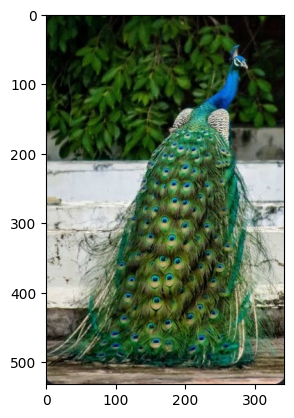

In [5]:
img  = load_img(r"C:\Users\Yashasvi\Documents\Deep-Learning-Project\CNN\peacock\testing\pec5.jpg")
plt.imshow(img)

In [6]:
il=cv2.imread(r"C:\Users\Yashasvi\Documents\Deep-Learning-Project\CNN\peacock\testing\pec5.jpg")
il

array([[[45, 31, 35],
        [48, 37, 40],
        [47, 36, 38],
        ...,
        [44, 36, 36],
        [43, 35, 35],
        [42, 34, 34]],

       [[48, 34, 38],
        [44, 33, 35],
        [43, 35, 36],
        ...,
        [40, 32, 32],
        [44, 36, 36],
        [45, 37, 37]],

       [[45, 34, 36],
        [44, 33, 35],
        [44, 36, 37],
        ...,
        [40, 34, 35],
        [42, 36, 37],
        [44, 36, 36]],

       ...,

       [[39, 34, 33],
        [42, 37, 36],
        [45, 40, 41],
        ...,
        [36, 31, 30],
        [39, 34, 33],
        [46, 41, 40]],

       [[46, 41, 40],
        [37, 32, 31],
        [35, 30, 29],
        ...,
        [37, 32, 31],
        [42, 37, 36],
        [45, 40, 39]],

       [[41, 36, 35],
        [39, 34, 33],
        [40, 35, 34],
        ...,
        [43, 38, 37],
        [39, 34, 33],
        [38, 33, 32]]], shape=(532, 343, 3), dtype=uint8)

In [7]:
il.shape

(532, 343, 3)

In [12]:
train = ImageDataGenerator(rescale=1/255)
validation=ImageDataGenerator(rescale=1/255)

train_dataset = train.flow_from_directory(r"C:\Users\Yashasvi\Documents\Deep-Learning-Project\CNN\training",target_size=(224,224),batch_size=32,class_mode='binary')
validation_dataset = validation.flow_from_directory(r"C:\Users\Yashasvi\Documents\Deep-Learning-Project\CNN\validation",target_size=(224,224),batch_size=32,class_mode='binary')


Found 6 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


In [13]:
train_dataset.class_indices

{'parrot': 0, 'peacock': 1}

In [14]:
train_dataset.classes

array([0, 0, 0, 1, 1, 1], dtype=int32)

In [25]:
# now we are applying maxpooling

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [26]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics = ['accuracy']
              )

In [27]:
model_fit = model.fit(train_dataset,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6904
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step - accuracy: 0.5000 - loss: 3.8808
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5000 - loss: 5.5902
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6667 - loss: 0.5554
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8333 - loss: 0.4148
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6667 - loss: 0.4002
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6667 - loss: 0.5118
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6667 - loss: 0.3192
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 1.0000 - loss: 0.1487
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0790


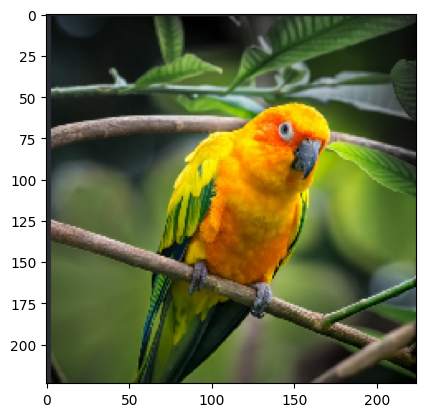

it is a parrot


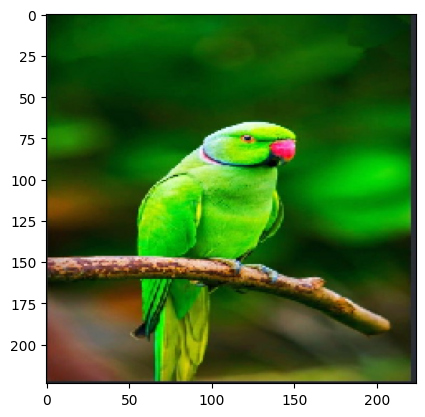

it is a peacock


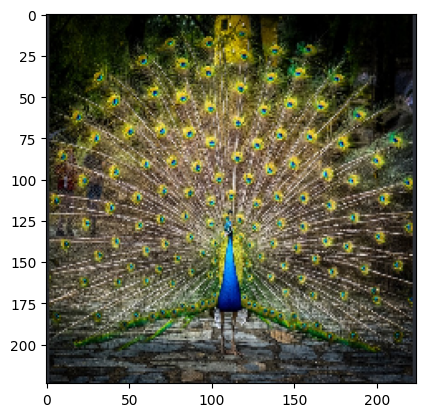

it is a peacock


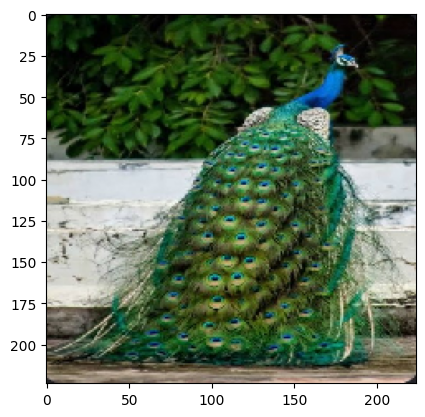

it is a peacock


In [ ]:
dir_path = r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\CNN\testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (224,224))# change dimension to 224,224
    plt.imshow(img)
    plt.show()
        
    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
  
    
    val = model.predict(x,verbose=0)
    if val == 0:
        print( 'it is a parrot')
    else:
        print('it is a peacock')     